# DSA210 Milestone 1  
## Movie Success Analysis Using TMDB and IMDb Data

This notebook covers the April 14 milestone requirements:
- data collection
- data cleaning and merging
- exploratory data analysis (EDA)
- hypothesis testing


## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load Data

Place these files in the same folder as this notebook:
- `tmdb_5000_movies.csv`
- `title.basics.tsv`
- `title.ratings.tsv`

If your files are in another folder, replace the filenames below with full paths.


In [2]:
tmdb = pd.read_csv("tmdb_5000_movies.csv")
basics = pd.read_csv("title.basics.tsv", sep="\t")
ratings = pd.read_csv("title.ratings.tsv", sep="\t")

print("TMDB shape:", tmdb.shape)
print("IMDb basics shape:", basics.shape)
print("IMDb ratings shape:", ratings.shape)

TMDB shape: (4803, 20)
IMDb basics shape: (12435536, 9)
IMDb ratings shape: (1660809, 3)


## 3. Clean IMDb Data

We keep only movies and only the columns needed for this project.


In [3]:
basics = basics[basics["titleType"] == "movie"]
basics = basics[["tconst", "primaryTitle", "startYear"]]
ratings = ratings[["tconst", "averageRating", "numVotes"]]

imdb = pd.merge(basics, ratings, on="tconst")
imdb.rename(columns={"primaryTitle": "title", "startYear": "year"}, inplace=True)

print("IMDb merged shape:", imdb.shape)
imdb.head()

IMDb merged shape: (342269, 5)


,tconst,title,year,averageRating,numVotes
0,tt0000009,Miss Jerry,1894,5.3,237
1,tt0000147,The Corbett-Fitzsimmons Fight,1897,5.3,601
2,tt0000502,Bohemios,1905,3.5,26
3,tt0000574,The Story of the Kelly Gang,1906,6.0,1068
4,tt0000591,The Prodigal Son,1907,5.0,39


## 4. Clean TMDB Data

We keep the main movie-related columns and remove entries with zero budget or zero revenue so that financial analysis is meaningful.


In [4]:
tmdb = tmdb[["title", "budget", "revenue", "popularity", "genres", "release_date"]]
tmdb = tmdb[(tmdb["budget"] > 0) & (tmdb["revenue"] > 0)]

print("TMDB cleaned shape:", tmdb.shape)
tmdb.head()

TMDB cleaned shape: (3229, 6)


,title,budget,revenue,popularity,genres,release_date
0,Avatar,237000000,2787965087,150.437577,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",2009-12-10
1,Pirates of the Caribbean: At World's End,300000000,961000000,139.082615,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",2007-05-19
2,Spectre,245000000,880674609,107.376788,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",2015-10-26
3,The Dark Knight Rises,250000000,1084939099,112.312950,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",2012-07-16
4,John Carter,260000000,284139100,43.926995,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",2012-03-07


## 5. Merge TMDB and IMDb

The two datasets are merged on movie title to combine financial data with audience-based data.


In [5]:
df = pd.merge(tmdb, imdb, on="title")

print("Final merged shape:", df.shape)
df.head()

Final merged shape: (5770, 10)


,title,budget,revenue,popularity,genres,release_date,tconst,year,averageRating,numVotes
0,Avatar,237000000,2787965087,150.437577,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",2009-12-10,tt0154182,1941,6.4,26
1,Avatar,237000000,2787965087,150.437577,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",2009-12-10,tt0278325,1916,7.0,30
2,Avatar,237000000,2787965087,150.437577,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",2009-12-10,tt0499549,2009,7.9,1494178
3,Avatar,237000000,2787965087,150.437577,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",2009-12-10,tt1775309,2011,5.2,131
4,Pirates of the Caribbean: At World's End,300000000,961000000,139.082615,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",2007-05-19,tt0449088,2007,7.2,742379


## 6. Feature Engineering / Enrichment

New variables are created to improve the analysis:
- `profit = revenue - budget`
- `ROI = revenue / budget`
- release decade
- success category based on profit


**Interpretation:**  
The number of movies increases in recent decades. This may reflect growth in the film industry or dataset bias toward more recent films.

In [6]:
df["profit"] = df["revenue"] - df["budget"]
df["ROI"] = df["revenue"] / df["budget"]

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year_tmdb"] = df["release_date"].dt.year
df["decade"] = (df["year_tmdb"] // 10) * 10

def success_category(profit):
    if profit < 0:
        return "Low"
    elif profit < 100_000_000:
        return "Medium"
    else:
        return "High"

df["success_category"] = df["profit"].apply(success_category)

df[["title", "budget", "revenue", "averageRating", "numVotes", "profit", "ROI", "decade", "success_category"]].head()

,title,budget,revenue,averageRating,numVotes,profit,ROI,decade,success_category
0,Avatar,237000000,2787965087,6.4,26,2550965087,11.763566,2000,High
1,Avatar,237000000,2787965087,7.0,30,2550965087,11.763566,2000,High
2,Avatar,237000000,2787965087,7.9,1494178,2550965087,11.763566,2000,High
3,Avatar,237000000,2787965087,5.2,131,2550965087,11.763566,2000,High
4,Pirates of the Caribbean: At World's End,300000000,961000000,7.2,742379,661000000,3.203333,2000,High


## 7. Exploratory Data Analysis (EDA)

### 7.1 Budget vs Revenue
This scatter plot shows whether higher-budget films tend to generate higher revenue.


**Interpretation:**  
There is a clear positive relationship between budget and revenue. Movies with higher budgets tend to generate higher revenue, although the spread is large. This suggests that budget is an important factor but not the only determinant of success.

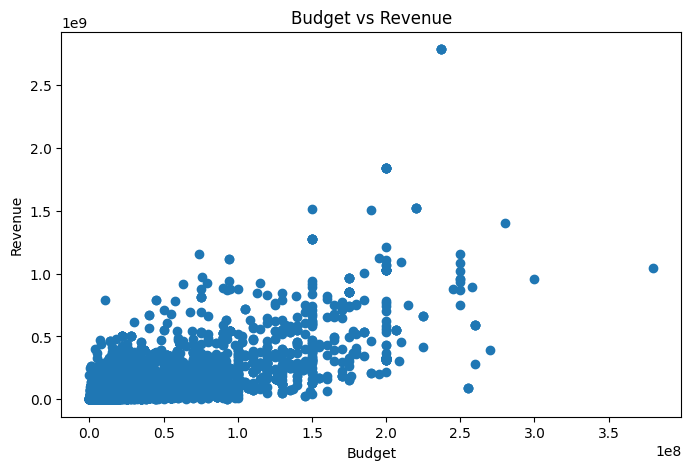

In [7]:
plt.scatter(df["budget"], df["revenue"])
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue")
plt.show()

**Interpretation:**  
The scatter plot suggests a positive relationship between budget and revenue. Movies with larger budgets tend to generate higher revenues on average, although the spread is quite wide. This means budget appears to be an important factor, but it is not sufficient on its own to explain movie success.


### 7.2 Rating vs Revenue
This scatter plot shows the relationship between IMDb rating and revenue.


**Interpretation:**  
The relationship between IMDb rating and revenue is weak. Although some highly rated movies earn high revenue, many do not. This indicates that rating alone is not a strong predictor of financial success.

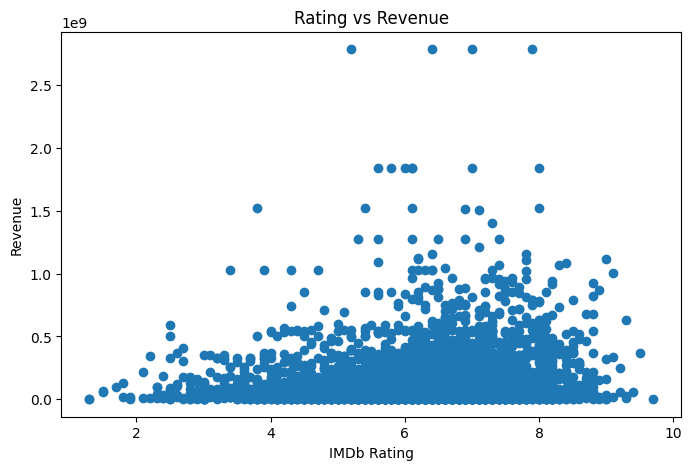

In [8]:
plt.scatter(df["averageRating"], df["revenue"])
plt.xlabel("IMDb Rating")
plt.ylabel("Revenue")
plt.title("Rating vs Revenue")
plt.show()

**Interpretation:**  
The relationship between IMDb rating and revenue appears weaker than the relationship between budget and revenue. While some highly rated movies earn very large revenue, many highly rated films still have moderate or low revenue. This suggests that audience rating may matter, but financial performance is influenced by several other factors.


### 7.3 Profit Distribution
This histogram shows how movie profits are distributed.


**Interpretation:**  
The distribution is heavily right-skewed. Most movies have relatively low profit, while a small number achieve very high profits. This shows that success is uneven and dominated by a few blockbuster films.

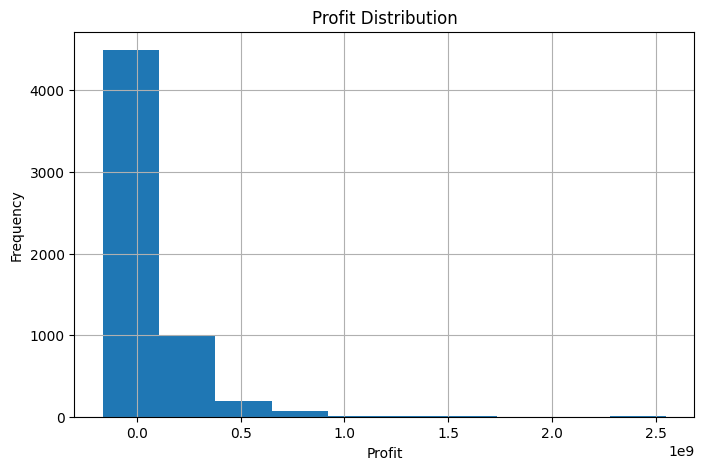

In [9]:
df["profit"].hist()
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

**Interpretation:**  
The profit distribution is strongly right-skewed. Most movies have relatively modest profit values, while a small number of films achieve extremely large profits. This suggests that movie profitability is unevenly distributed and includes several strong outliers.


**Interpretation:**  
The distribution is heavily right-skewed. Most movies have relatively low profit, while a small number achieve very high profits. This shows that success is uneven and dominated by a few blockbuster films.

### 7.4 Number of Movies by Decade
This plot helps us observe whether the number of movies in the dataset changes across decades.


**Interpretation:**  
The number of movies increases in recent decades. This may reflect growth in the film industry or dataset bias toward more recent films.

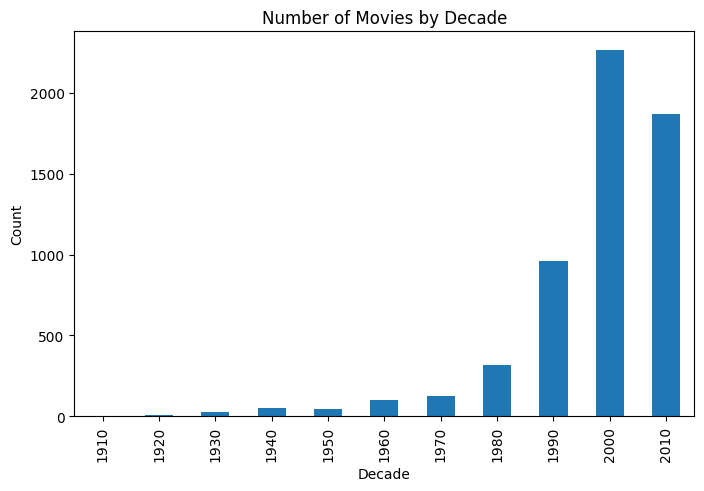

In [10]:
df["decade"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Movies by Decade")
plt.xlabel("Decade")
plt.ylabel("Count")
plt.show()

**Interpretation:**  
This bar chart shows how movies are distributed across release decades in the merged dataset. It helps us understand the temporal structure of the data and whether some decades are represented more heavily than others.


**Interpretation:**  
The number of movies increases in recent decades. This may reflect growth in the film industry or dataset bias toward more recent films.

### 7.5 Budget vs Revenue (Log Scale)
Because budget and revenue contain very large outliers, a log-scale plot can make the relationship easier to see.


**Interpretation:**  
There is a clear positive relationship between budget and revenue. Movies with higher budgets tend to generate higher revenue, although the spread is large. This suggests that budget is an important factor but not the only determinant of success.

**Interpretation:**  
Using a log scale makes the relationship between budget and revenue clearer by reducing the effect of extreme values. The positive trend remains visible.

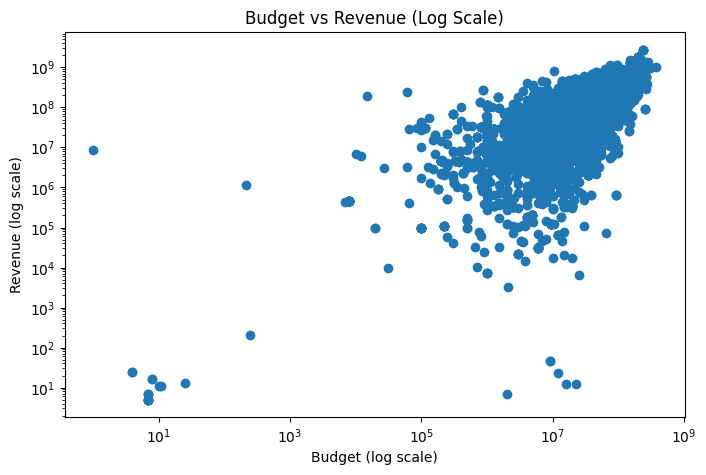

In [11]:
plt.scatter(df["budget"], df["revenue"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Budget (log scale)")
plt.ylabel("Revenue (log scale)")
plt.title("Budget vs Revenue (Log Scale)")
plt.show()

**Interpretation:**  
The log-scale version makes the positive relationship between budget and revenue easier to observe by compressing extreme values. This confirms the general upward trend while making the structure of the data clearer.


## 8. Hypothesis Testing

### Hypothesis Test 1: Budget and Revenue

- **H0:** There is no linear relationship between budget and revenue.  
- **H1:** There is a linear relationship between budget and revenue.


In [12]:
corr_budget_revenue, p_budget_revenue = pearsonr(df["budget"], df["revenue"])
print("Budget-Revenue correlation:", corr_budget_revenue)
print("p-value:", p_budget_revenue)

Budget-Revenue correlation: 0.6825261615227394
p-value: 0.0


**Interpretation:**  
If the p-value is smaller than 0.05, we reject H0 and conclude that budget and revenue have a statistically significant linear relationship.


### Hypothesis Test 2: IMDb Rating and Revenue

- **H0:** There is no linear relationship between IMDb rating and revenue.  
- **H1:** There is a linear relationship between IMDb rating and revenue.


In [13]:
corr_rating_revenue, p_rating_revenue = pearsonr(df["averageRating"], df["revenue"])
print("Rating-Revenue correlation:", corr_rating_revenue)
print("p-value:", p_rating_revenue)

Rating-Revenue correlation: 0.08717992426772542
p-value: 3.2797547431577935e-11


**Interpretation:**  
If the p-value is smaller than 0.05, we reject H0 and conclude that IMDb rating and revenue have a statistically significant linear relationship.


## 9. Short Conclusion

This milestone combined financial movie data from TMDB with audience-based data from IMDb. After cleaning and merging the datasets, exploratory analysis showed a positive relationship between budget and revenue, while the relationship between IMDb rating and revenue appeared weaker. Profit values were highly skewed, with a small number of movies earning very large profits. Hypothesis tests were included to evaluate the statistical significance of the observed relationships.


## 10. Optional: Save Cleaned Dataset
You can run the following line to save the merged and cleaned dataset for later milestones.


In [14]:
df.to_csv("cleaned_movies.csv", index=False)

## Hypothesis Interpretations

**Budget vs Revenue:**  
There is a strong positive correlation (~0.68) with a very small p-value, so we reject H0 and conclude that budget significantly affects revenue.

**Rating vs Revenue:**  
The correlation is very weak (~0.087), although the p-value is small. This means the relationship is statistically significant but not practically meaningful.